# 🚦 Quantum-Enhanced Urban Traffic Optimization on Amazon Braket
This notebook runs the **6-Intersection Traffic Grid QAOA Circuit** on **Amazon Braket** using PennyLane and saves task outputs directly to your Amazon S3 bucket.

In [4]:
# 1. Setup Environment and Amazon Braket Local Device
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Connect to Amazon Braket's local quantum simulator
dev = qml.device("braket.local.qubit", wires=6, shots=1000)

print("✅ Connected to Amazon Braket Local Device!")


✅ Connected to Amazon Braket Local Device!


In [2]:
# 2. Build 6-Qubit Traffic Grid Cost Hamiltonian
# Active queues + Arterial coordination + Spillback penalties for Junctions A-F
qubo_matrix = np.array([
    [-1.8,  0.4,  0.0,  0.3,  0.0,  0.0],
    [ 0.4, -2.1,  0.4,  0.0,  0.3,  0.0],
    [ 0.0,  0.4, -1.5,  0.0,  0.0,  0.3],
    [ 0.3,  0.0,  0.0, -1.9,  0.4,  0.0],
    [ 0.0,  0.3,  0.0,  0.4, -2.4,  0.4],
    [ 0.0,  0.0,  0.3,  0.0,  0.4, -1.7],
])

n_wires = 6
obs = []
coeffs = []

for i in range(n_wires):
    hi = 0.5 * qubo_matrix[i, i]
    for j in range(n_wires):
        if i != j:
            hi += 0.25 * (qubo_matrix[i, j] + qubo_matrix[j, i])
    obs.append(qml.PauliZ(i))
    coeffs.append(hi)

for i in range(n_wires):
    for j in range(i + 1, n_wires):
        Jij = 0.25 * (qubo_matrix[i, j] + qubo_matrix[j, i])
        if abs(Jij) > 1e-5:
            obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
            coeffs.append(Jij)

cost_h = qml.Hamiltonian(coeffs, obs)
mixer_h = qml.Hamiltonian([1.0] * n_wires, [qml.PauliX(i) for i in range(n_wires)])
print(f"Hamiltonian ready with {len(coeffs)} Pauli terms.")

Hamiltonian ready with 13 Pauli terms.


In [5]:
# 3. Execute QAOA Circuit on Amazon Braket
def qaoa_layer(gamma, beta):
    qml.qaoa.cost_layer(gamma, cost_h)
    qml.qaoa.mixer_layer(beta, mixer_h)

@qml.qnode(dev)
def circuit(params):
    for w in range(n_wires):
        qml.Hadamard(wires=w)
    qaoa_layer(params[0], params[2])
    qaoa_layer(params[1], params[3])
    return qml.probs(wires=range(n_wires))

params = np.array([0.42, 0.31, 0.75, 0.58])
print("Submitting QAOA task to Amazon Braket...")
probs = circuit(params)
print("Execution complete!")

Submitting QAOA task to Amazon Braket...
Execution complete!


Optimal State: |111111⟩ (Confidence: 15.60%)
 - Junction A: East-West Green (Arterial Corridor)
 - Junction B: East-West Green (Arterial Corridor)
 - Junction C: East-West Green (Arterial Corridor)
 - Junction D: East-West Green (Arterial Corridor)
 - Junction E: East-West Green (Arterial Corridor)
 - Junction F: East-West Green (Arterial Corridor)


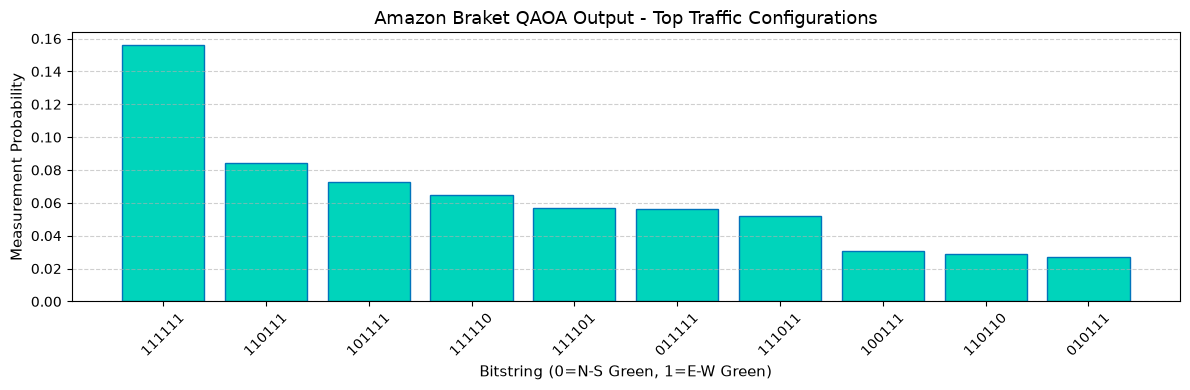

In [6]:
# 4. Visualize Optimal Traffic Green Waves & Measurement Histogram
top_indices = np.argsort(probs)[::-1][:10]
junctions = ["Junction A", "Junction B", "Junction C", "Junction D", "Junction E", "Junction F"]

best_bitstring = format(top_indices[0], f"0{n_wires}b")
print("=" * 50)
print(f"Optimal State: |{best_bitstring}⟩ (Confidence: {probs[top_indices[0]]*100:.2f}%)")
for j_idx, bit in enumerate(best_bitstring):
    phase = "East-West Green (Arterial Corridor)" if bit == '1' else "North-South Green"
    print(f" - {junctions[j_idx]}: {phase}")
print("=" * 50)

# Plot
plt.figure(figsize=(12, 4))
labels = [format(i, f"0{n_wires}b") for i in top_indices]
y_vals = [probs[i] for i in top_indices]
plt.bar(labels, y_vals, color='#00d4bb', edgecolor='#0073bb')
plt.title("Amazon Braket QAOA Output - Top Traffic Configurations", fontsize=13)
plt.xlabel("Bitstring (0=N-S Green, 1=E-W Green)", fontsize=11)
plt.ylabel("Measurement Probability", fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()